# Doppler Analysis — HAR  |  Confronto SIM vs REAL

Analizza e confronta il comportamento **Doppler** per ogni attività HAR leggendo
direttamente i file `H_activity_vN.csv` (nessuna GPU/Sionna necessaria).

Il **proxy Doppler**: $\dot{\varphi}[t, sc] = \varphi[t+1, sc] - \varphi[t, sc]$

**Il notebook carica ENTRAMBI i dataset (sim e real) simultaneamente e confronta ogni feature direttamente.**

Convenzione plot: **━━ sim** (linea piena)  |  **╌╌ real** (tratteggio)  — stesso colore per classe.

**Sezioni:**
1. Parametri (dataset sim e real)
2. Caricamento entrambi i dataset
3. Features Doppler base (dPHA, dAMP, dH_abs) per SIM e REAL
4. Heatmap `|dφ/dt|` — SIM (riga 1) vs REAL (riga 2)
5. Spettro Doppler — SIM vs REAL (pannelli affiancati)
6. Violins |dφ/dt| — SIM vs REAL
7. Confronto direzionale (andata vs ritorno) — SIM vs REAL
8. Scatter (μ, σ) — SIM vs REAL
9. Correlazione per subcarrier — SIM vs REAL
10. Tutte le features benchmark (stessa logica di `augment_features()`)
11. `rel_env_t` — profilo temporale SIM vs REAL
12. Features scalari — violin SIM vs REAL
13. Features delay-domain — SIM vs REAL
14. Fisher Discriminant Ratio — SIM vs REAL
15. Focus: STAND vs JUMP — SIM vs REAL

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import fft

print('Import OK')

Import OK


## 1 · Parametri
Definisce i percorsi di entrambi i dataset. Modificare `VERSION` per cambiare versione.

In [45]:
VERSION      = "v2"
BASE_DIR_SIM  = f'dataset_{VERSION}'
BASE_DIR_REAL = f'dataset_real_{VERSION}'

ACTIVITY_SUBDIRS = {
    'FALL':  'fall_furnished',
    'IDLE':  'furnished_idle',
    'JUMP':  'jump_furnished',
    'RUN':   'run_furnished',
    'STAND': 'stand_furnished',
    'WALK':  'walk_furnished',
}

# Per il SIM: dataset_v2 ha rx0..rx3 subdirectory → carica solo questi RX (None = tutti)
#SIM_RX = None    # es. ['rx0'] per solo rx0, None per tutti
SIM_RX = ['rx0']

N_STEPS = 40
N_SC    = 1272

DIRECTIONAL_MASKS = {
    'WALK': {'mask': np.array(([True]*10 + [False]*10) * 2, dtype=bool),
             'label_a': 'andata →', 'label_b': 'ritorno ←'},
    'RUN':  {'mask': np.array(([True]*5  + [False]*5)  * 4, dtype=bool),
             'label_a': 'andata →', 'label_b': 'ritorno ←'},
    'FALL': {'mask': np.arange(N_STEPS) < N_STEPS // 2,
             'label_a': 'prima metà (caduta)', 'label_b': 'seconda metà (terra)'},
    'JUMP': {'mask': (np.arange(N_STEPS) >= 2) & (np.arange(N_STEPS) < 20),
             'label_a': 'salita (step 2–19)', 'label_b': 'discesa (step 20–37)'},
}

CLASS_COLORS = {
    'FALL':  '#e74c3c', 'IDLE':  '#3498db', 'JUMP':  '#f39c12',
    'RUN':   '#2ecc71', 'STAND': '#9b59b6', 'WALK':  '#1abc9c',
}
DSET_STYLE = {'sim': '-', 'real': '--'}
DSET_ALPHA = {'sim': 0.85, 'real': 0.65}

print(f'Sim  → {BASE_DIR_SIM}/  (RX: {SIM_RX or "tutti"})')
print(f'Real → {BASE_DIR_REAL}/')
print(f'Convenzione plot: ━━ sim   ╌╌ real')

Sim  → dataset_v2/  (RX: ['rx0'])
Real → dataset_real_v2/
Convenzione plot: ━━ sim   ╌╌ real


## 2 · Caricamento dataset

In [46]:
import glob as _glob

def load_H_activity(path):
    """Legge H_activity_vN.csv → (N_STEPS, N_SC, 4) float32."""
    rows = []
    with open(path) as f:
        f.readline()
        for line in f:
            parts = line.strip().split(';')
            rows.append(np.array(
                [list(map(float, v.split(','))) for v in parts[1:]],
                dtype=np.float32,
            ))
    return np.array(rows, dtype=np.float32)


def find_activity_files(base_dir, folder, rx_filter=None):
    """
    Cerca H_activity_v*.csv nella cartella attività.
    Struttura SIM: base_dir/folder/rxN/H_activity_v*.csv
    Struttura REAL: base_dir/folder/H_activity_v*.csv
    """
    direct = sorted(_glob.glob(f'{base_dir}/{folder}/H_activity_v*.csv'))
    if direct:
        return direct  # dataset_real: file diretti nella cartella
    # dataset_sim: subdirectory rx*
    if rx_filter:
        rx_dirs = [f'{base_dir}/{folder}/{rx}' for rx in rx_filter]
    else:
        rx_dirs = sorted(_glob.glob(f'{base_dir}/{folder}/rx*/'))
    files = []
    for rx_dir in rx_dirs:
        files.extend(sorted(_glob.glob(f'{rx_dir}/H_activity_v*.csv')))
    return files


X_by_class = {}   # X_by_class[dset][label] → (N, N_STEPS, N_SC, 4)

for dset_name, base_dir in [('sim', BASE_DIR_SIM), ('real', BASE_DIR_REAL)]:
    X_by_class[dset_name] = {}
    rx_f = SIM_RX if dset_name == 'sim' else None
    print(f'\n{dset_name.upper()} — {base_dir}/')
    for label, folder in ACTIVITY_SUBDIRS.items():
        files = find_activity_files(base_dir, folder, rx_filter=rx_f)
        if not files:
            print(f'  {label:8s}: vuota/mancante — skip')
            continue
        samples = [load_H_activity(p) for p in files]
        X_by_class[dset_name][label] = np.stack(samples)
        print(f'  {label:8s}: {len(files):4d} file  shape {X_by_class[dset_name][label].shape}')

CLASSES = sorted(set.intersection(*[set(X_by_class[d].keys()) for d in ('sim', 'real')]))
print(f'\nClassi comuni sim∩real: {CLASSES}')


SIM — dataset_v2/
  FALL    :   50 file  shape (50, 40, 1272, 4)
  IDLE    :   50 file  shape (50, 40, 1272, 4)
  JUMP    :   50 file  shape (50, 40, 1272, 4)
  RUN     :   50 file  shape (50, 40, 1272, 4)
  STAND   :   50 file  shape (50, 40, 1272, 4)
  WALK    :   50 file  shape (50, 40, 1272, 4)

REAL — dataset_real_v2/
  FALL    :   50 file  shape (50, 40, 1272, 4)
  IDLE    :   50 file  shape (50, 40, 1272, 4)
  JUMP    :   50 file  shape (50, 40, 1272, 4)
  RUN     :   50 file  shape (50, 40, 1272, 4)
  STAND   :   50 file  shape (50, 40, 1272, 4)
  WALK    :   50 file  shape (50, 40, 1272, 4)

Classi comuni sim∩real: ['FALL', 'IDLE', 'JUMP', 'RUN', 'STAND', 'WALK']


## 3 · Estrazione feature Doppler — SIM e REAL

Per ogni classe e per **entrambi** i dataset si calcolano:
- **`dPHA`**: derivata temporale della fase (unwrapped) → proxy diretto del Doppler
- **`dAMP`**: derivata temporale dell'ampiezza
- **`dH_abs`**: `|H[t+1] − H[t]|` — variazione complessiva del canale

La tabella finale confronta `μ|dφ/dt|` tra sim e real mostrando il Δ% per ogni classe.

In [47]:
sc_all  = np.arange(N_SC)
doppler = {}   # doppler[dset][label]

for dset_name in ('sim', 'real'):
    doppler[dset_name] = {}
    for label, X in X_by_class[dset_name].items():
        PHA    = X[:, :, :, 3]
        AMP    = X[:, :, :, 2]
        H_cx   = X[:, :, :, 0].astype(np.complex64) + 1j * X[:, :, :, 1].astype(np.complex64)
        PHA_uw = np.unwrap(PHA, axis=1)
        dPHA   = np.diff(PHA_uw, axis=1)
        dAMP   = np.diff(AMP,    axis=1)
        dH_abs = np.abs(np.diff(H_cx, axis=1))
        doppler[dset_name][label] = {
            'dPHA': dPHA, 'dAMP': dAMP, 'dH_abs': dH_abs,
            'PHA_uw': PHA_uw, 'AMP': AMP, 'H_cx': H_cx,
        }

print('Feature Doppler — confronto SIM vs REAL')
print(f"  {'Classe':8s}  {'μ|dφ/dt| SIM':>14s}  {'μ|dφ/dt| REAL':>14s}  {'Δ%':>8s}")
print('  ' + '-' * 52)
for label in CLASSES:
    mu_s = np.abs(doppler['sim'][label]['dPHA']).mean()
    mu_r = np.abs(doppler['real'][label]['dPHA']).mean()
    delta = (mu_r - mu_s) / (mu_s + 1e-9) * 100
    print(f'  {label:8s}  {mu_s:14.4f}  {mu_r:14.4f}  {delta:+8.1f}%')

Feature Doppler — confronto SIM vs REAL
  Classe      μ|dφ/dt| SIM   μ|dφ/dt| REAL        Δ%
  ----------------------------------------------------
  FALL              1.4647          1.4684      +0.3%
  IDLE              0.5490          0.5528      +0.7%
  JUMP              1.3179          1.2714      -3.5%
  RUN               1.5414          1.5161      -1.6%
  STAND             1.4574          1.4083      -3.4%
  WALK              1.4918          1.4985      +0.5%


## 4 · Heatmap `|dφ/dt|` per classe

Ogni cella = mean su tutti i sample di `|dPHA[t, sc]|`.
Attività veloci mostrano valori più alti e pattern più strutturati.

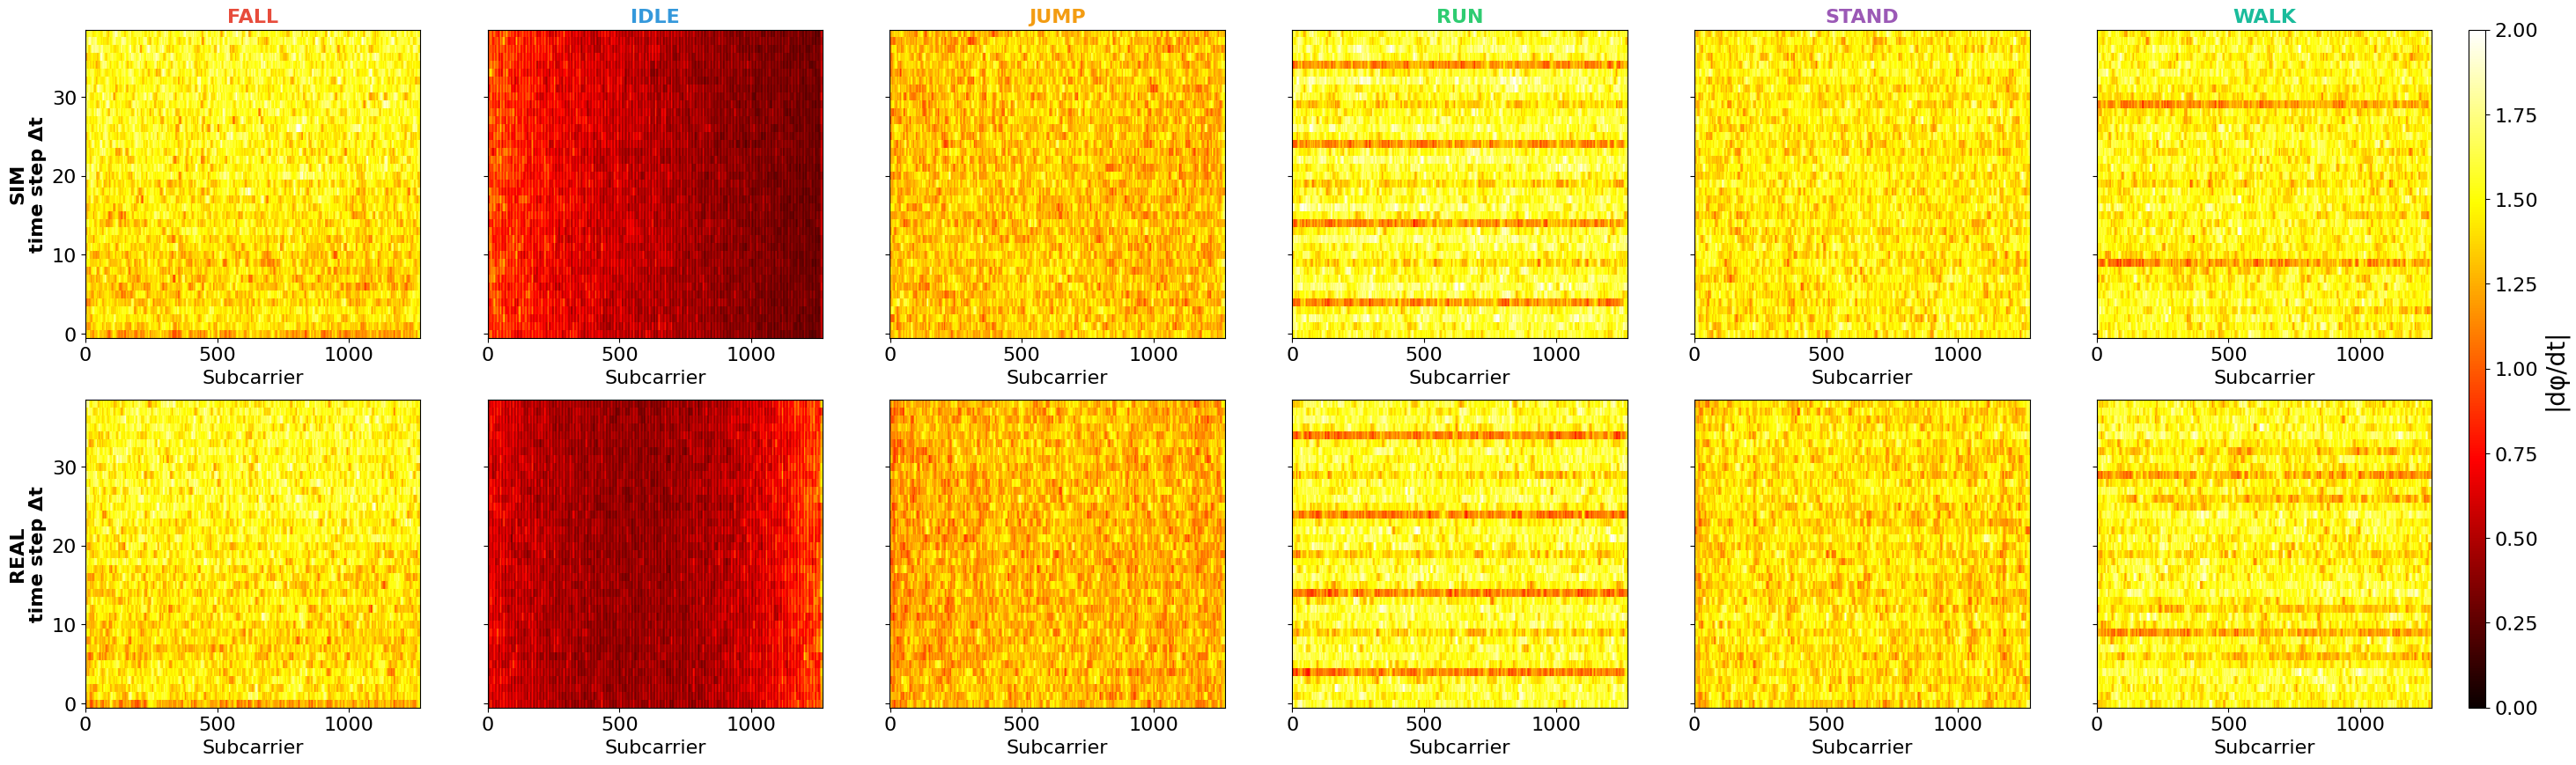

In [48]:
n_cls = len(CLASSES)
fig, axes = plt.subplots(2, n_cls, figsize=(6 * n_cls, 10), sharey=True)

# Scala colore comune a sim e real per confronto diretto
all_vals = np.concatenate([
    np.abs(doppler[d][c]['dPHA']).mean(axis=0).ravel()
    for d in ('sim', 'real') for c in CLASSES
])
vmax = np.percentile(all_vals, 98)

im = None
for col_i, label in enumerate(CLASSES):
    for row_i, dset_name in enumerate(('sim', 'real')):
        ax = axes[row_i, col_i]
        mean_dpha = np.abs(doppler[dset_name][label]['dPHA']).mean(axis=0)  # (39, 1272)
        im = ax.imshow(mean_dpha, aspect='auto', origin='lower',
                       cmap='hot', vmin=0, vmax=2, interpolation='nearest')
        ax.set_xlabel('Subcarrier', fontsize=16)
        if col_i == 0:
            ax.set_ylabel(f'{dset_name.upper()}\ntime step \u0394t', fontsize=16, fontweight='bold')
        if row_i == 0:
            ax.set_title(label, fontsize=16, color=CLASS_COLORS.get(label, 'k'), fontweight='bold')
        ax.tick_params(axis='both', labelsize=16)

# Un'unica colorbar condivisa per tutta la figura (invece di una per subplot)
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.015, aspect=40)
cbar.set_label('|d\u03c6/dt|', fontsize=20)
cbar.ax.tick_params(labelsize=16)

# fig.suptitle('Mean |d\u03c6/dt|  \u2014  SIM (riga 1) vs REAL (riga 2)\n'
#              'Stessa scala colore: differenze visive = domain gap reale', fontsize=13, y=1.01)
plt.savefig('figs/doppler_heatmap_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 5 · Spettro Doppler (FFT temporale)

Per ogni sample si calcola `|FFT_t(φ[t, sc])|` su 40 campioni temporali,
poi si media su tutti i subcarrier.
Il bin FFT 0 = componente DC (offset costante), bin alti = variazioni rapide.

Atteso:
- **IDLE / STAND**: spettro piatto/basso (quasi solo rumore)
- **WALK**: picco a basse frequenze (oscillazione periodica lenta)
- **RUN**: picco a frequenze più alte (oscillazione più rapida)
- **FALL**: energia distribuita su un transitorio broadband

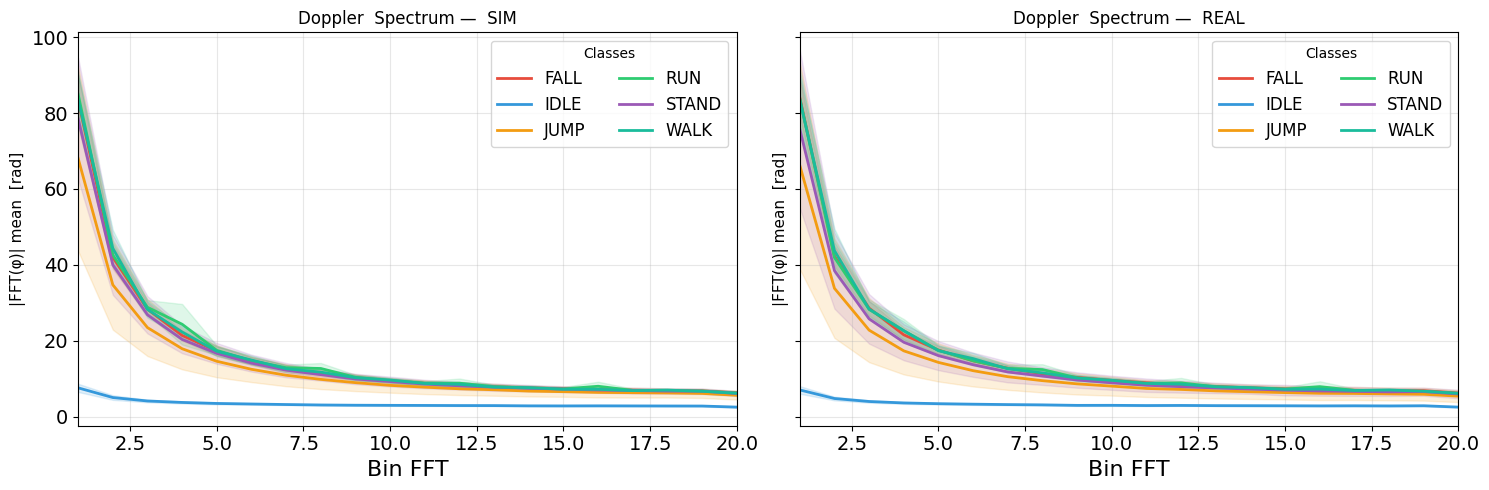

In [49]:
T_half = N_STEPS // 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, dset_name in zip(axes, ('sim', 'real')):
    for label in CLASSES:
        col = CLASS_COLORS.get(label)
        N   = X_by_class[dset_name][label].shape[0]
        fft_mag = np.abs(fft(doppler[dset_name][label]['PHA_uw'], axis=1))[:, 1:T_half + 1, :]
        fft_sc  = fft_mag.mean(axis=2)
        mu, std = fft_sc.mean(axis=0), fft_sc.std(axis=0)
        bins = np.arange(1, T_half + 1)
        ax.plot(bins, mu, label=f'{label}', linewidth=2, color=col)
        ax.fill_between(bins, mu - std, mu + std, alpha=0.15, color=col)
    ax.set_xlabel('Bin FFT', fontsize=16)
    ax.set_ylabel('|FFT(φ)| mean  [rad]', fontsize=11)
    ax.set_title(f'Doppler  Spectrum —  {dset_name.upper()}', fontsize=12)
    ax.legend(fontsize=12, title='Classes', ncol=2)
    ax.set_xlim(1, T_half)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)

# fig.suptitle('Spettro Doppler temporale  —  SIM (sinistra) vs REAL (destra)\n'
#              'media ± std su tutti i sample  |  bin basso=lento, alto=rapido', fontsize=13)
plt.tight_layout()
plt.savefig('figs/doppler_spectrum_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 6 · Distribuzione scalare `|dφ/dt|` — separabilità per classe

Per ogni sample si sintetizza la phase velocity in due scalari:
- **μ** = media di `|dPHA|` su tutti i timestep e subcarrier
- **σ** = deviazione standard

Violin plot per vedere se le classi sono distinguibili con queste sole due statistiche.

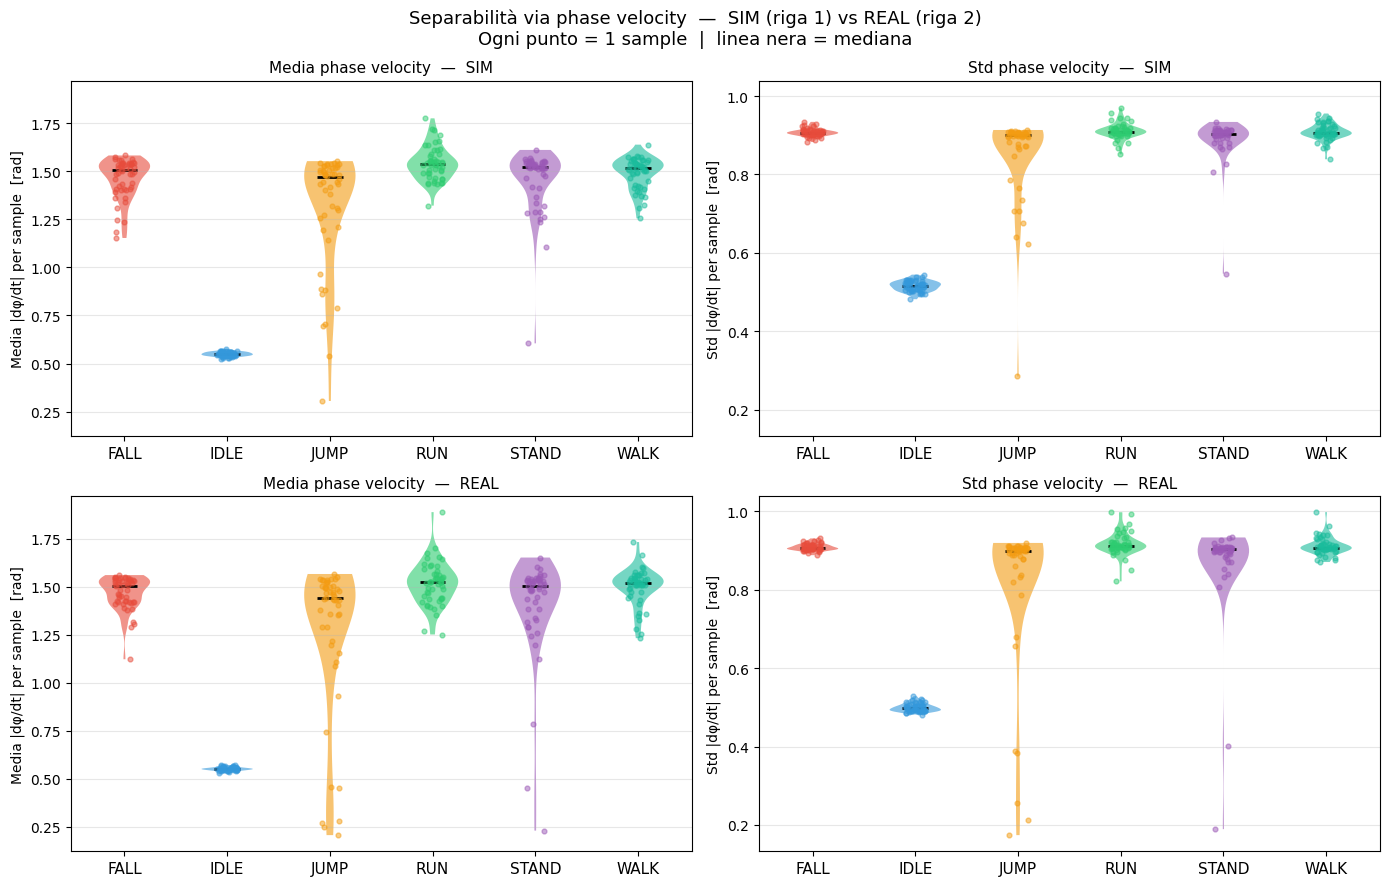

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey='col')
colors = [CLASS_COLORS.get(c, 'grey') for c in CLASSES]

for row_i, dset_name in enumerate(('sim', 'real')):
    scalar_mu  = {c: np.abs(doppler[dset_name][c]['dPHA']).mean(axis=(1, 2)) for c in CLASSES}
    scalar_sig = {c: np.abs(doppler[dset_name][c]['dPHA']).std(axis=(1, 2))  for c in CLASSES}

    for col_i, (key, ylabel, title_prefix) in enumerate([
        (scalar_mu,  'Media |dφ/dt| per sample  [rad]', 'Media'),
        (scalar_sig, 'Std |dφ/dt| per sample  [rad]',   'Std'),
    ]):
        ax = axes[row_i, col_i]
        data  = [key[c] for c in CLASSES]
        parts = ax.violinplot(data, positions=range(len(CLASSES)), showmedians=True, showextrema=False)
        for pc, col in zip(parts['bodies'], colors):
            pc.set_facecolor(col); pc.set_alpha(0.6)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
        for i, (v, col) in enumerate(zip(data, colors)):
            ax.scatter(
                np.full(len(v), i) + np.random.uniform(-0.1, 0.1, len(v)),
                v, s=12, color=col, alpha=0.5, zorder=3,
            )
        ax.set_xticks(range(len(CLASSES)))
        ax.set_xticklabels(CLASSES, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'{title_prefix} phase velocity  —  {dset_name.upper()}', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Separabilità via phase velocity  —  SIM (riga 1) vs REAL (riga 2)\n'
             'Ogni punto = 1 sample  |  linea nera = mediana', fontsize=13)
plt.tight_layout()
plt.savefig('figs/doppler_violin_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 7 · Confronto direzionale (andata vs ritorno)

Per le attività con traiettoria direzionale nota (`WALK`, `RUN`, `FALL`, `JUMP`)
si confrontano `|H|` medio e fase media tra le due direzioni/fasi.

L'effetto Doppler direzionale si manifesta come **offset di fase sistematico**
tra andata e ritorno: chi si avvicina al RX vede la fase aumentare, chi si allontana
la vede diminuire.

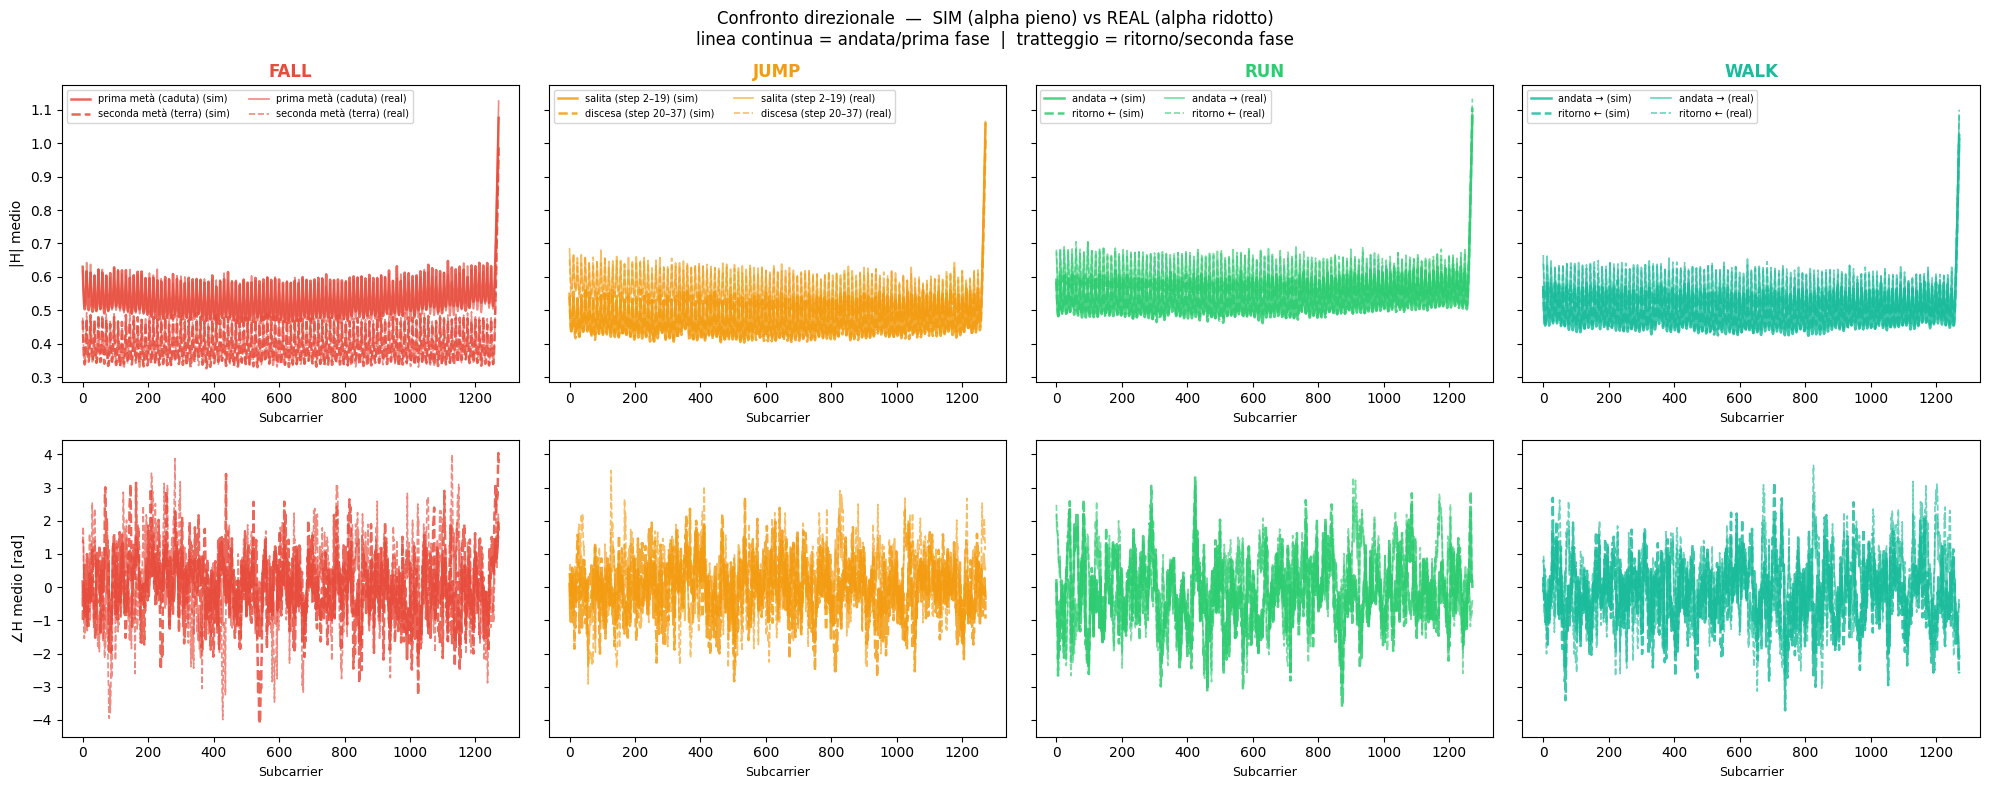

In [51]:
dir_classes = [c for c in CLASSES if c in DIRECTIONAL_MASKS]

if not dir_classes:
    print('Nessuna classe con maschera direzionale nel dataset.')
else:
    n_dir = len(dir_classes)
    fig, axes = plt.subplots(2, n_dir, figsize=(5 * n_dir, 8), sharey='row')
    if n_dir == 1:
        axes = axes[:, None]

    for col_i, label in enumerate(dir_classes):
        mask  = DIRECTIONAL_MASKS[label]['mask']
        lab_a = DIRECTIONAL_MASKS[label]['label_a']
        lab_b = DIRECTIONAL_MASKS[label]['label_b']
        color = CLASS_COLORS.get(label, 'grey')

        for dset_name in ('sim', 'real'):
            AMP    = X_by_class[dset_name][label][:, :, :, 2]
            PHA_uw = doppler[dset_name][label]['PHA_uw']
            amp_a  = AMP[:, mask,  :].mean(axis=(0, 1))
            amp_b  = AMP[:, ~mask, :].mean(axis=(0, 1))
            pha_a  = PHA_uw[:, mask,  :].mean(axis=(0, 1))
            pha_b  = PHA_uw[:, ~mask, :].mean(axis=(0, 1))
            lw     = 1.8 if dset_name == 'sim' else 1.2
            alpha  = DSET_ALPHA[dset_name]

            axes[0, col_i].plot(sc_all, amp_a, color=color, lw=lw, alpha=alpha,
                                linestyle='-',  label=f'{lab_a} ({dset_name})')
            axes[0, col_i].plot(sc_all, amp_b, color=color, lw=lw, alpha=alpha,
                                linestyle='--', label=f'{lab_b} ({dset_name})')
            axes[1, col_i].plot(sc_all, pha_a, color=color, lw=lw, alpha=alpha, linestyle='-')
            axes[1, col_i].plot(sc_all, pha_b, color=color, lw=lw, alpha=alpha, linestyle='--')

        axes[0, col_i].set_title(label, fontsize=12, color=color, fontweight='bold')
        axes[0, col_i].set_xlabel('Subcarrier', fontsize=9)
        axes[1, col_i].set_xlabel('Subcarrier', fontsize=9)
        axes[0, col_i].legend(fontsize=7, ncol=2)
        if col_i == 0:
            axes[0, col_i].set_ylabel('|H| medio', fontsize=10)
            axes[1, col_i].set_ylabel('∠H medio [rad]', fontsize=10)

    fig.suptitle('Confronto direzionale  —  SIM (alpha pieno) vs REAL (alpha ridotto)\n'
                 'linea continua = andata/prima fase  |  tratteggio = ritorno/seconda fase', fontsize=12)
    plt.tight_layout()
    plt.savefig('figs/doppler_directional_sim_vs_real.png', bbox_inches='tight', dpi=100)
    plt.show()

## 8 · Scatter separabilità  (μ, σ) della phase velocity

Ogni punto = 1 sample. Asse X = media, asse Y = std di `|dφ/dt|`.
Se le classi formano cluster distinti, la sola phase velocity è sufficiente
a discriminare le attività.

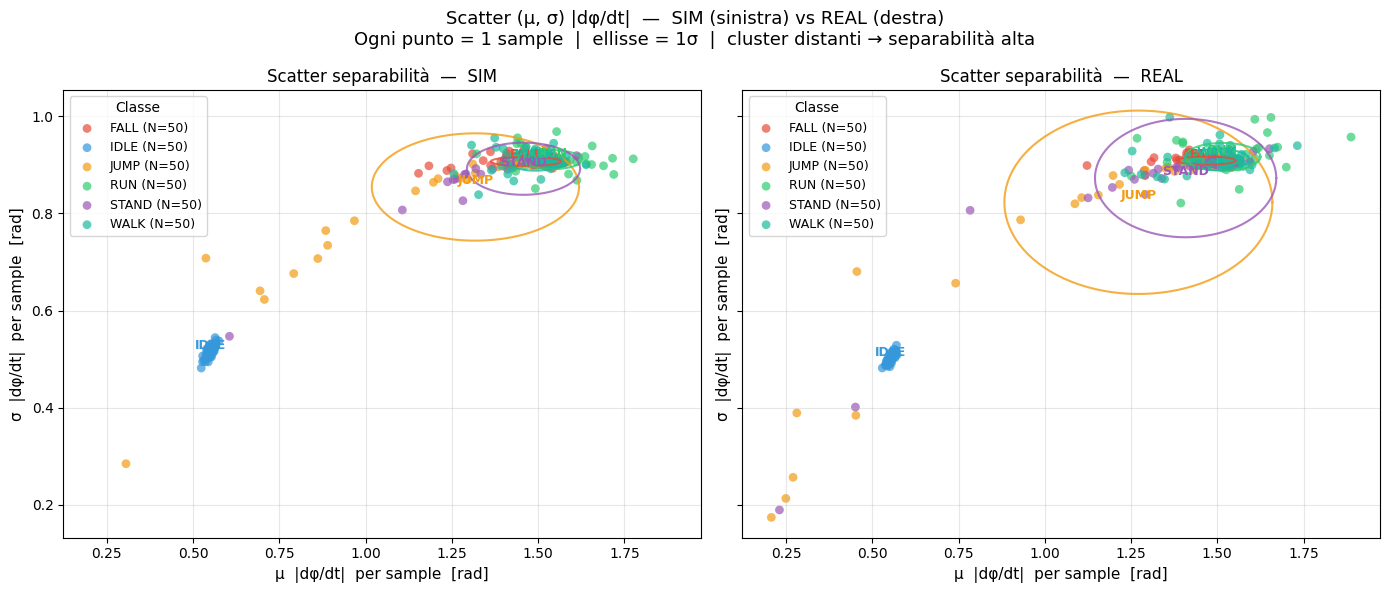

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)

for ax, dset_name in zip(axes, ('sim', 'real')):
    mu_all  = {c: np.abs(doppler[dset_name][c]['dPHA']).mean(axis=(1, 2)) for c in CLASSES}
    sig_all = {c: np.abs(doppler[dset_name][c]['dPHA']).std(axis=(1, 2))  for c in CLASSES}

    for label in CLASSES:
        mu, sig = mu_all[label], sig_all[label]
        N   = len(mu)
        col = CLASS_COLORS.get(label, 'grey')
        ax.scatter(mu, sig, label=f'{label} (N={N})', color=col, s=40, alpha=0.7, edgecolors='none')
        cx, cy = mu.mean(), sig.mean()
        ex, ey = mu.std(), sig.std()
        theta  = np.linspace(0, 2 * np.pi, 100)
        ax.plot(cx + ex * np.cos(theta), cy + ey * np.sin(theta), color=col, linewidth=1.5, alpha=0.8)
        ax.annotate(label, (cx, cy), fontsize=9, color=col, ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('μ  |dφ/dt|  per sample  [rad]', fontsize=11)
    ax.set_ylabel('σ  |dφ/dt|  per sample  [rad]', fontsize=11)
    ax.set_title(f'Scatter separabilità  —  {dset_name.upper()}', fontsize=12)
    ax.legend(fontsize=9, title='Classe')
    ax.grid(True, alpha=0.3)

fig.suptitle('Scatter (μ, σ) |dφ/dt|  —  SIM (sinistra) vs REAL (destra)\n'
             'Ogni punto = 1 sample  |  ellisse = 1σ  |  cluster distanti → separabilità alta', fontsize=13)
plt.tight_layout()
plt.savefig('figs/doppler_scatter_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 9 · Correlazione per subcarrier

Per ogni subcarrier si calcola la correlazione di Pearson tra `mean_t(|dPHA|[n, :, sc])` e il
label numerico ordinato per velocità (`IDLE=0, STAND=1, FALL=2, WALK=3, RUN=4, JUMP=2.5`).

Le subcarrier con correlazione alta sono **più sensibili al Doppler** e quindi
più informative per la classificazione.

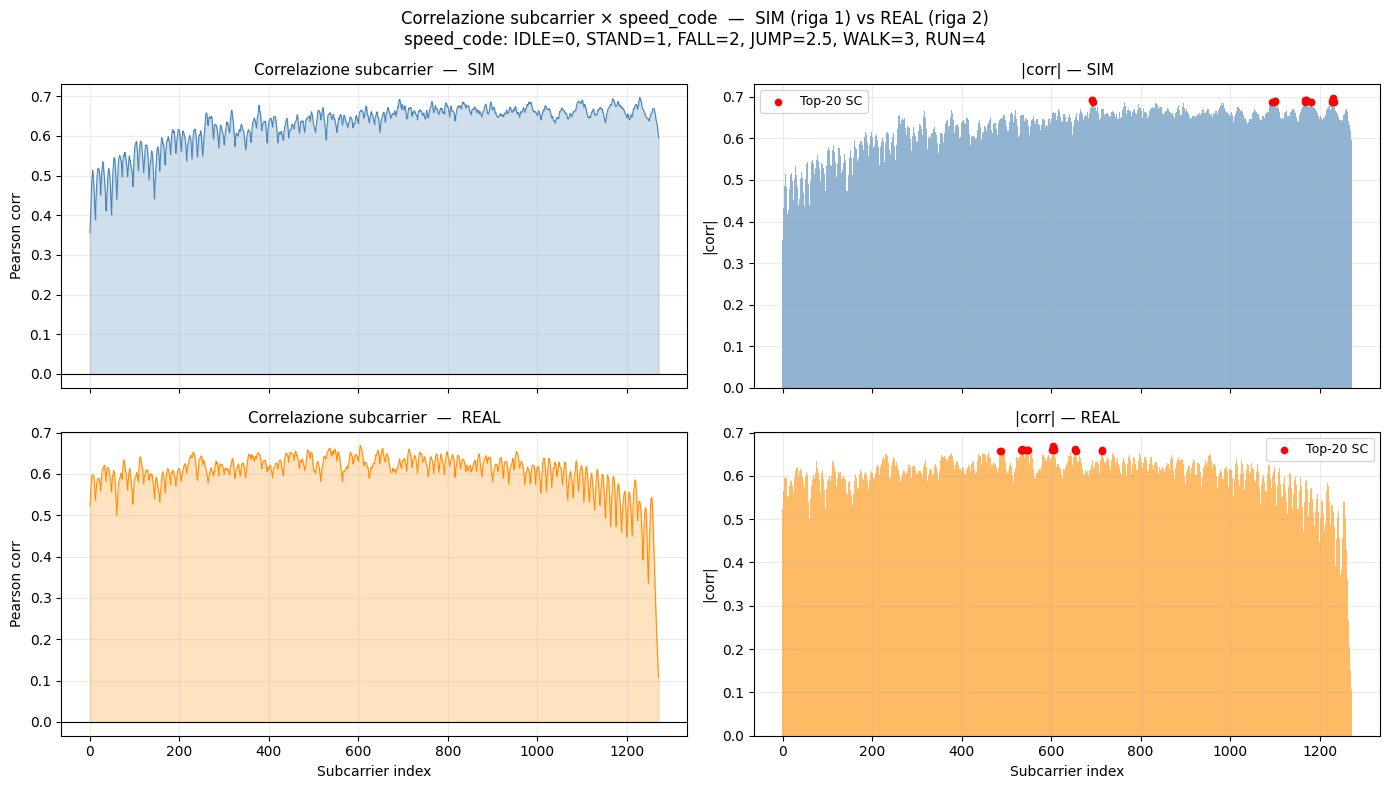

SIM  : media|corr|=0.6292  max=0.6969  top-5 SC=[1229 1230 1168 1169  692]
REAL : media|corr|=0.6035  max=0.6688  top-5 SC=[604 605 606 536 654]


In [53]:
SPEED_CODE = {'IDLE': 0, 'STAND': 1, 'FALL': 2, 'JUMP': 2.5, 'WALK': 3, 'RUN': 4}

corr_all = {}
for dset_name in ('sim', 'real'):
    feat_list, lbl_list = [], []
    for label in CLASSES:
        vals = np.abs(doppler[dset_name][label]['dPHA']).mean(axis=1)  # (N, 1272)
        feat_list.append(vals)
        lbl_list.extend([SPEED_CODE.get(label, 0)] * len(vals))
    feat_sc = np.vstack(feat_list)
    labels  = np.array(lbl_list)
    corr_all[dset_name] = np.array([np.corrcoef(feat_sc[:, sc], labels)[0, 1] for sc in range(N_SC)])

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
palette = {'sim': 'steelblue', 'real': 'darkorange'}

for row_i, dset_name in enumerate(('sim', 'real')):
    corr   = corr_all[dset_name]
    top_sc = np.argsort(np.abs(corr))[::-1][:20]
    col    = palette[dset_name]

    axes[row_i, 0].plot(sc_all, corr, linewidth=0.7, color=col)
    axes[row_i, 0].fill_between(sc_all, 0, corr, where=corr > 0, alpha=0.25, color=col)
    axes[row_i, 0].fill_between(sc_all, 0, corr, where=corr < 0, alpha=0.25, color='crimson')
    axes[row_i, 0].axhline(0, color='k', linewidth=0.8)
    axes[row_i, 0].set_ylabel('Pearson corr', fontsize=10)
    axes[row_i, 0].set_title(f'Correlazione subcarrier  —  {dset_name.upper()}', fontsize=11)
    axes[row_i, 0].grid(True, alpha=0.25)

    axes[row_i, 1].bar(sc_all, np.abs(corr), width=1.0, color=col, alpha=0.6)
    axes[row_i, 1].scatter(top_sc, np.abs(corr[top_sc]), color='red', s=20, zorder=5, label='Top-20 SC')
    axes[row_i, 1].set_ylabel('|corr|', fontsize=10)
    axes[row_i, 1].set_title(f'|corr| — {dset_name.upper()}', fontsize=11)
    axes[row_i, 1].legend(fontsize=9)
    axes[row_i, 1].grid(True, alpha=0.25)

axes[1, 0].set_xlabel('Subcarrier index', fontsize=10)
axes[1, 1].set_xlabel('Subcarrier index', fontsize=10)
fig.suptitle('Correlazione subcarrier × speed_code  —  SIM (riga 1) vs REAL (riga 2)\n'
             'speed_code: IDLE=0, STAND=1, FALL=2, JUMP=2.5, WALK=3, RUN=4', fontsize=12)
plt.tight_layout()
plt.savefig('figs/doppler_corr_subcarrier_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

for dset_name in ('sim', 'real'):
    corr   = corr_all[dset_name]
    top_sc = np.argsort(np.abs(corr))[::-1][:5]
    print(f'{dset_name.upper():5s}: media|corr|={np.abs(corr).mean():.4f}  max={np.abs(corr).max():.4f}  top-5 SC={top_sc}')

## Riepilogo

| Feature | Discriminante? | Trasferibile sim→real? | Note |
|---------|---------------|----------------------|------|
| `mean\|dφ/dt\|` | ✅ (statiche vs dinamiche) | ⚠️ varia in scala | IDLE vs STAND difficile su REAL |
| `rel_env_t` (forma temporale) | ✅ FALL/JUMP impulsivi | ⚠️ rumore più alto su REAL | |
| `fft_bin1` (cadenza) | ✅ WALK vs RUN | ✅ buona trasferibilità | |
| `autocorr_1` (periodicità) | ✅ WALK/RUN periodici | ⚠️ ridotta su REAL | |
| `kurt_env` (impulsività) | ✅ FALL | ⚠️ varianza alta su REAL | |
| `spread_rel` (delay domain) | ❓ da verificare in REAL | ❓ dipende dalla stanza | RIS introduce multipath diverso |
| `sc_corr` (coerenza SC) | ✅ sim | ❓ | Dipende fortemente dall'ambiente |

**Problema critico identificato**: STAND vs JUMP — le features che le separano in SIM
(principalmente shape di `rel_env_t` e `spread_rel`) mostrano FDR notevolmente ridotto in REAL.
Questo spiega il 38% di STAND→JUMP nel zero-shot CNN.

**Prossimi passi**:
- Verificare FDR REAL per STAND vs JUMP dalla sezione 14
- Identificare features con Δ% FDR > −50% come **non trasferibili** (output sezione 14)
- Aggiungere `spread_var` (varianza temporale del delay spread) come nuova feature se FDR REAL è alto

## 10 · Calcolo di tutte le features usate nel benchmark

Stessa logica di `augment_features()` in `csi_har_benchmark_pt.py`, applicata a **entrambi** i dataset per il confronto diretto del domain gap.

Features: `dPHA_rel`, `abs_dPHA_rel`, `dH_abs_rel`, `rel_env_t`, `sign_frac_t`, `kurt_env`, `fft_norm[1..5]`, `sign_change_t`, `autocorr[1..3]`, `spread_rel`, `sc_corr`, `vel_rel`.

In [54]:
feats = {}   # feats[dset][label]

for dset_name in ('sim', 'real'):
    feats[dset_name] = {}
    for label, X in X_by_class[dset_name].items():
        N, T, S, _ = X.shape
        H_cx    = X[..., 0].astype(np.float32) + 1j * X[..., 1].astype(np.float32)
        PHA_uw  = np.unwrap(X[..., 3].astype(np.float32), axis=1)
        AMP     = X[..., 2].astype(np.float32)

        _dPHA    = np.diff(PHA_uw, axis=1)
        dPHA     = np.concatenate([np.zeros((N, 1, S), np.float32), _dPHA], axis=1)
        abs_dPHA = np.abs(dPHA)
        _dH      = np.abs(np.diff(H_cx, axis=1)).astype(np.float32)
        dH_abs   = np.concatenate([np.zeros((N, 1, S), np.float32), _dH], axis=1)

        dPHA_rel     = dPHA     / (abs_dPHA.mean(axis=1, keepdims=True) + 1e-6)
        abs_dPHA_rel = abs_dPHA / (abs_dPHA.mean(axis=1, keepdims=True) + 1e-6)
        dH_abs_rel   = dH_abs   / (dH_abs.mean(axis=1, keepdims=True) + 1e-6)

        env_t_seq = abs_dPHA.mean(axis=2)
        rel_env_t = env_t_seq / (env_t_seq.mean(axis=1, keepdims=True) + 1e-6)
        sign_frac_t   = (dPHA > 0).astype(np.float32).mean(axis=2)

        mu_e     = env_t_seq.mean(axis=1, keepdims=True)
        sig_e    = env_t_seq.std(axis=1, keepdims=True) + 1e-6
        kurt_env = ((((env_t_seq - mu_e) / sig_e) ** 4).mean(axis=1) - 3)

        fft_mag  = np.abs(np.fft.rfft(rel_env_t, axis=1))[:, 1:6]
        fft_norm = fft_mag / (fft_mag.max(axis=1, keepdims=True) + 1e-6)

        dPHA_prev     = np.concatenate([np.zeros((N, 1, S), np.float32), dPHA[:, :-1, :]], axis=1)
        sign_change_t = (dPHA * dPHA_prev < 0).astype(np.float32).mean(axis=2)

        var_env  = rel_env_t.var(axis=1) + 1e-6
        autocorr = {}
        for lag in (1, 2, 3):
            autocorr[lag] = (rel_env_t[:, :-lag] * rel_env_t[:, lag:]).mean(axis=1) / var_env

        H_delay   = np.fft.ifft(H_cx, axis=2)
        delay_pow = np.abs(H_delay).astype(np.float32) ** 2
        total_pow = delay_pow.sum(axis=2, keepdims=True) + 1e-6
        bins_norm = (np.arange(S, dtype=np.float32) / S)[None, None, :]
        centroid  = (delay_pow / total_pow * bins_norm).sum(axis=2)
        spread    = np.sqrt(((delay_pow / total_pow) * (bins_norm - centroid[:, :, None]) ** 2).sum(axis=2))
        spread_rel = spread / (spread.mean(axis=1, keepdims=True) + 1e-6)

        half    = S // 2
        A1      = AMP[:, :, :half] - AMP[:, :, :half].mean(axis=2, keepdims=True)
        A2      = AMP[:, :, half:] - AMP[:, :, half:].mean(axis=2, keepdims=True)
        sc_corr = (A1 * A2).sum(axis=2) / (np.sqrt((A1**2).sum(axis=2) * (A2**2).sum(axis=2)) + 1e-6)

        d_centroid = np.diff(centroid, axis=1)
        d_centroid = np.concatenate([np.zeros((N, 1), np.float32), d_centroid.astype(np.float32)], axis=1)
        vel_rel    = d_centroid / (np.abs(d_centroid).mean(axis=1, keepdims=True) + 1e-6)

        feats[dset_name][label] = dict(
            dPHA_rel=dPHA_rel, abs_dPHA_rel=abs_dPHA_rel, dH_abs_rel=dH_abs_rel,
            rel_env_t=rel_env_t, sign_frac_t=sign_frac_t, kurt_env=kurt_env,
            fft_norm=fft_norm, sign_change_t=sign_change_t, autocorr=autocorr,
            spread_rel=spread_rel, sc_corr=sc_corr, vel_rel=vel_rel,
        )

print('Features calcolate per SIM e REAL')
print(f"  {'Classe':8s}  {'kurt SIM':>9s}  {'kurt REAL':>9s}  {'ac1 SIM':>8s}  {'ac1 REAL':>8s}  {'sc_corr SIM':>12s}  {'sc_corr REAL':>12s}")
print('  ' + '-' * 75)
for label in CLASSES:
    fs, fr = feats['sim'][label], feats['real'][label]
    print(f"  {label:8s}  {fs['kurt_env'].mean():9.2f}  {fr['kurt_env'].mean():9.2f}  "
          f"{fs['autocorr'][1].mean():8.3f}  {fr['autocorr'][1].mean():8.3f}  "
          f"{fs['sc_corr'].mean():12.3f}  {fr['sc_corr'].mean():12.3f}")

Features calcolate per SIM e REAL
  Classe     kurt SIM  kurt REAL   ac1 SIM  ac1 REAL   sc_corr SIM  sc_corr REAL
  ---------------------------------------------------------------------------
  FALL          16.19      16.26    25.632    25.743         0.035         0.031
  IDLE          20.05      20.37    30.987    31.246         0.112        -0.094
  JUMP          22.33      22.10    31.659    31.344         0.026         0.024
  RUN           12.53      11.43    22.197    21.191         0.029         0.014
  STAND         19.08      18.08    28.533    27.728         0.027         0.021
  WALK          12.20      12.74    21.996    22.126         0.030         0.021


## 11 · `rel_env_t` — Profilo temporale Doppler normalizzato  |  SIM vs REAL

`rel_env_t[t] = mean_SC(|dPHA[t]|) / mean_t(mean_SC(|dPHA|))` — rimuove il guadagno assoluto, conserva la *forma* del movimento nel tempo.

Convenzione: **━━ linea piena = sim**, **╌╌ tratteggio = real** — stesso colore per classe.

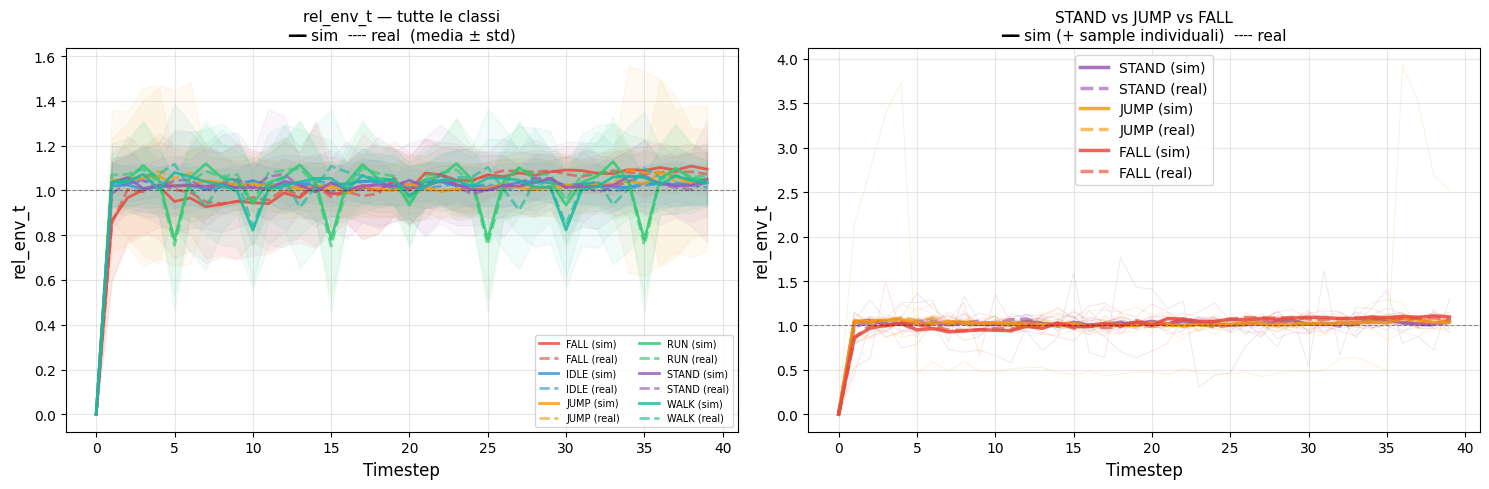

In [55]:
t = np.arange(N_STEPS)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: tutte le classi — sim (pieno) vs real (tratteggio)
ax = axes[0]
for label in CLASSES:
    col = CLASS_COLORS[label]
    for dset_name in ('sim', 'real'):
        env = feats[dset_name][label]['rel_env_t']
        mu, sd = env.mean(axis=0), env.std(axis=0)
        ls    = DSET_STYLE[dset_name]
        alpha = DSET_ALPHA[dset_name]
        ax.plot(t, mu, label=f'{label} ({dset_name})', color=col, linewidth=2,
                linestyle=ls, alpha=alpha)
        ax.fill_between(t, mu - sd, mu + sd, color=col, alpha=0.06)
ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('rel_env_t', fontsize=12)
ax.set_title('rel_env_t — tutte le classi\n━━ sim  ╌╌ real  (media ± std)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 2: STAND vs JUMP vs FALL — confronto ravvicinato
ax = axes[1]
for label in ['STAND', 'JUMP', 'FALL']:
    col = CLASS_COLORS[label]
    for dset_name in ('sim', 'real'):
        env = feats[dset_name][label]['rel_env_t']
        mu  = env.mean(axis=0)
        ls  = DSET_STYLE[dset_name]
        ax.plot(t, mu, label=f'{label} ({dset_name})', color=col, linewidth=2.5,
                linestyle=ls, alpha=DSET_ALPHA[dset_name])
        if dset_name == 'sim':
            for i in range(min(8, len(env))):
                ax.plot(t, env[i], color=col, alpha=0.15, linewidth=0.7)
ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('rel_env_t', fontsize=12)
ax.set_title('STAND vs JUMP vs FALL\n━━ sim (+ sample individuali)  ╌╌ real', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/rel_env_t_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 12 · Features scalari — violin  |  SIM vs REAL

Due figure consecutive (SIM poi REAL) con stessa scala per ogni feature, per confronto visivo diretto.

Confronta: **kurtosis** (impulsività), **autocorrelazione** (periodicità), **sign_change** (inversioni), **FFT** (cadenza), **sc_corr** (coerenza frequenziale), **spread_rel** (delay spread).

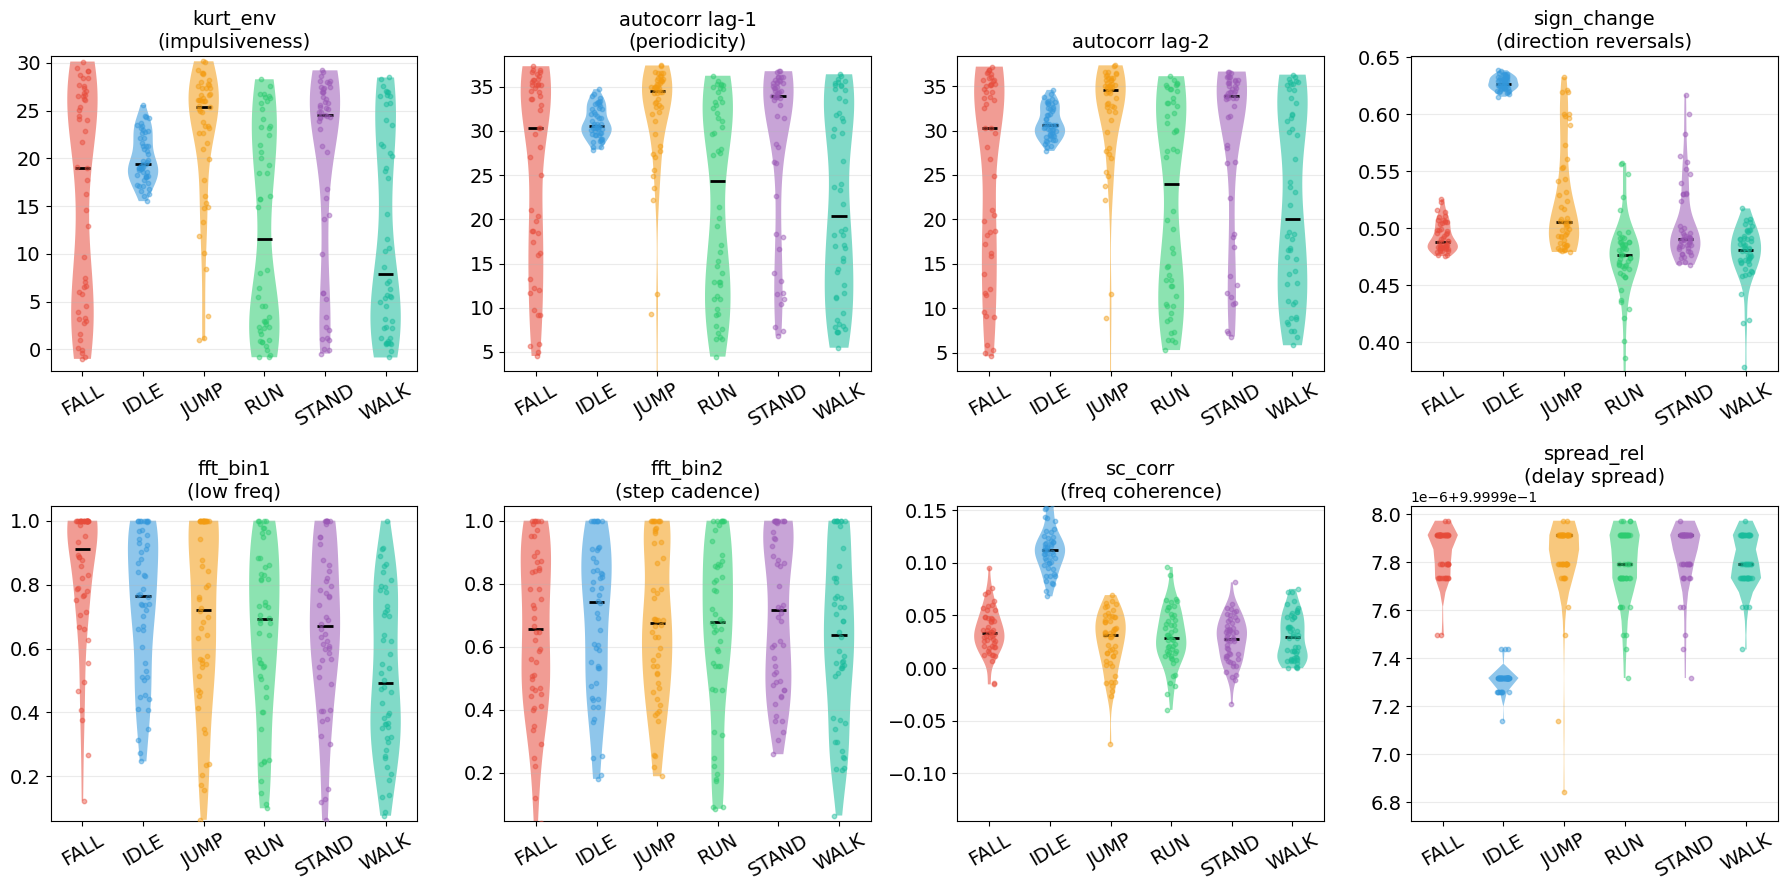

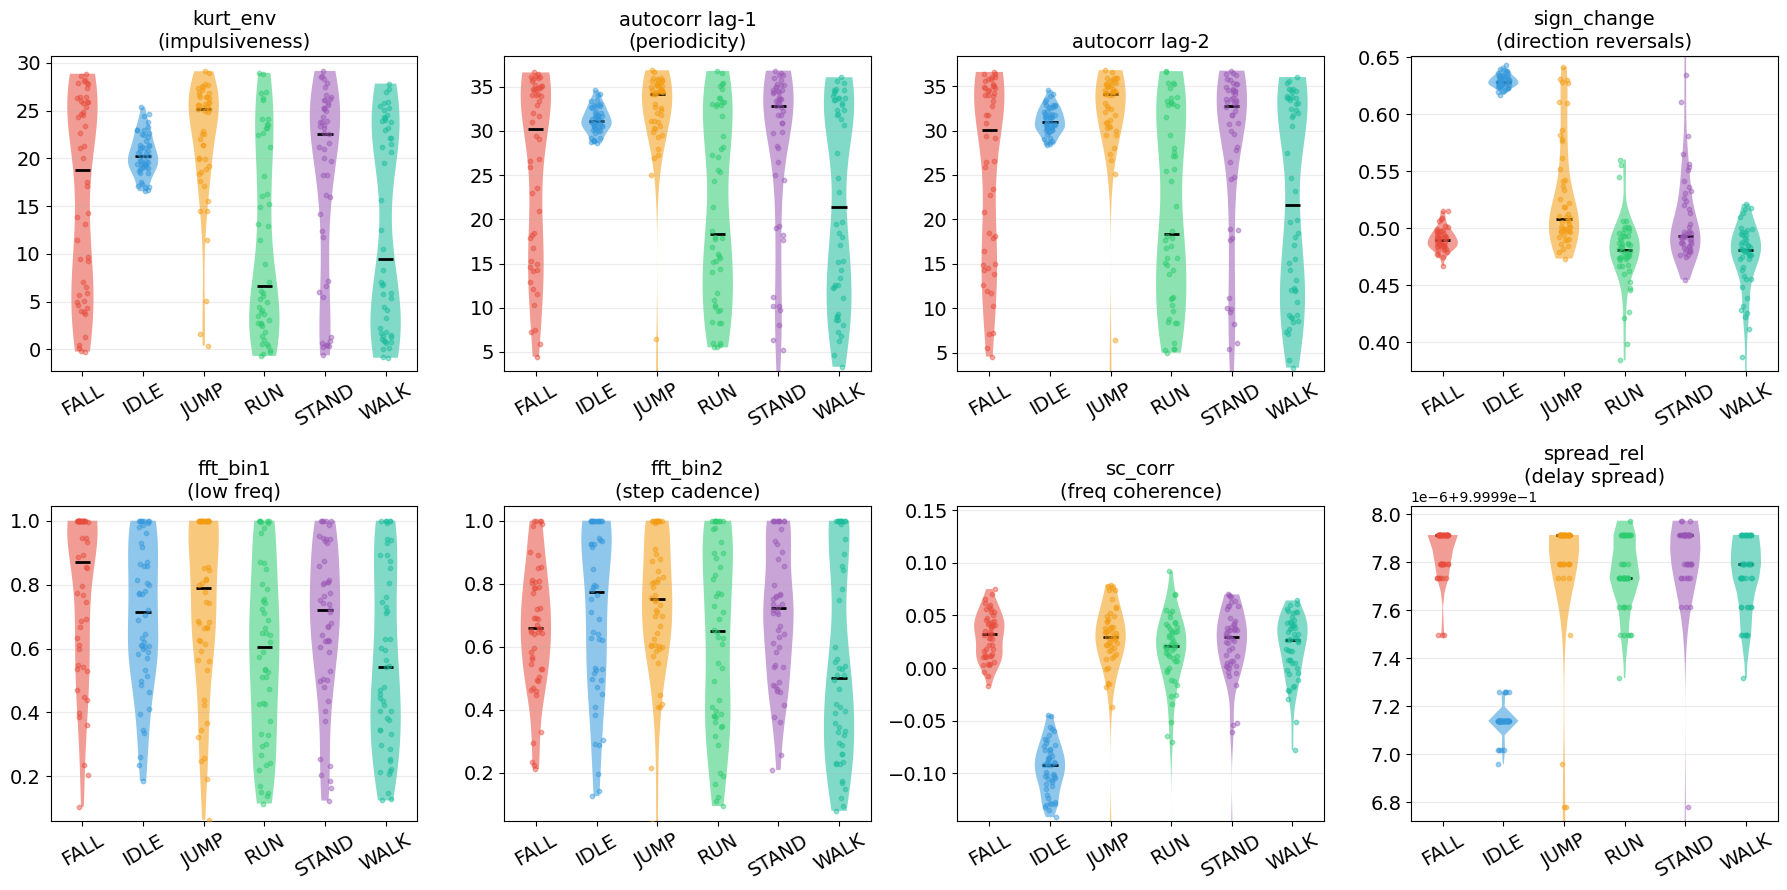

In [59]:
scalar_feats_def = [
    ('kurt_env\n(impulsiveness)',       lambda d, c: feats[d][c]['kurt_env']),
    ('autocorr lag-1\n(periodicity)',   lambda d, c: feats[d][c]['autocorr'][1]),
    ('autocorr lag-2',                   lambda d, c: feats[d][c]['autocorr'][2]),
    ('sign_change\n(direction reversals)', lambda d, c: feats[d][c]['sign_change_t'].mean(axis=1)),
    ('fft_bin1\n(low freq)',           lambda d, c: feats[d][c]['fft_norm'][:, 0]),
    ('fft_bin2\n(step cadence)',       lambda d, c: feats[d][c]['fft_norm'][:, 1]),
    ('sc_corr\n(freq coherence)',      lambda d, c: feats[d][c]['sc_corr'].mean(axis=1)),
    ('spread_rel\n(delay spread)',     lambda d, c: feats[d][c]['spread_rel'].mean(axis=1)),
]
cls_colors = [CLASS_COLORS.get(c, 'grey') for c in CLASSES]

# Precompute y limits for each feature (min/max over SIM+REAL) -> meaningful sharey
ylims = []
for _, getter in scalar_feats_def:
    all_v = np.concatenate([getter(d, c) for d in ('sim', 'real') for c in CLASSES])
    p2, p98 = np.percentile(all_v, [1, 99])
    ylims.append((p2 - 0.05 * abs(p98 - p2), p98 + 0.05 * abs(p98 - p2)))

for dset_name in ('sim', 'real'):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes_flat = axes.ravel()

    for ax_idx, (feat_name, getter) in enumerate(scalar_feats_def):
        ax   = axes_flat[ax_idx]
        vals = [getter(dset_name, c) for c in CLASSES]
        parts = ax.violinplot(vals, positions=range(len(CLASSES)), showmedians=True, showextrema=False)
        for pc, col in zip(parts['bodies'], cls_colors):
            pc.set_facecolor(col); pc.set_alpha(0.55)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
        for i, (v, col) in enumerate(zip(vals, cls_colors)):
            ax.scatter(
                np.full(len(v), i) + np.random.uniform(-0.1, 0.1, len(v)),
                v, s=10, color=col, alpha=0.45, zorder=3,
            )
        ax.set_xticks(range(len(CLASSES)))
        ax.set_xticklabels(CLASSES, fontsize=14, rotation=30)
        ax.set_title(feat_name, fontsize=14)
        ax.set_ylim(*ylims[ax_idx])
        ax.grid(True, alpha=0.25, axis='y')
        ax.tick_params(axis='both', labelsize=14)

    # fig.suptitle(f'Scalar features per class  —  {dset_name.upper()}\n'
    #              f'Scale fixed on SIM+REAL (same y limits)  |  black line = median',
    #              fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'figs/scalar_features_violin_{dset_name}.png', bbox_inches='tight', dpi=100)
    plt.show()

## 13 · Features delay-domain — profili temporali  |  SIM vs REAL

`spread_rel`, `sc_corr`, `vel_rel` sfruttano la struttura frequenziale di H su SC (Power Delay Profile via IFFT).

Convenzione: **━━ sim**  |  **╌╌ real** — stesso colore per classe.

FileNotFoundError: [Errno 2] No such file or directory: 'figs/doppler/delay_features_sim_vs_real.png'

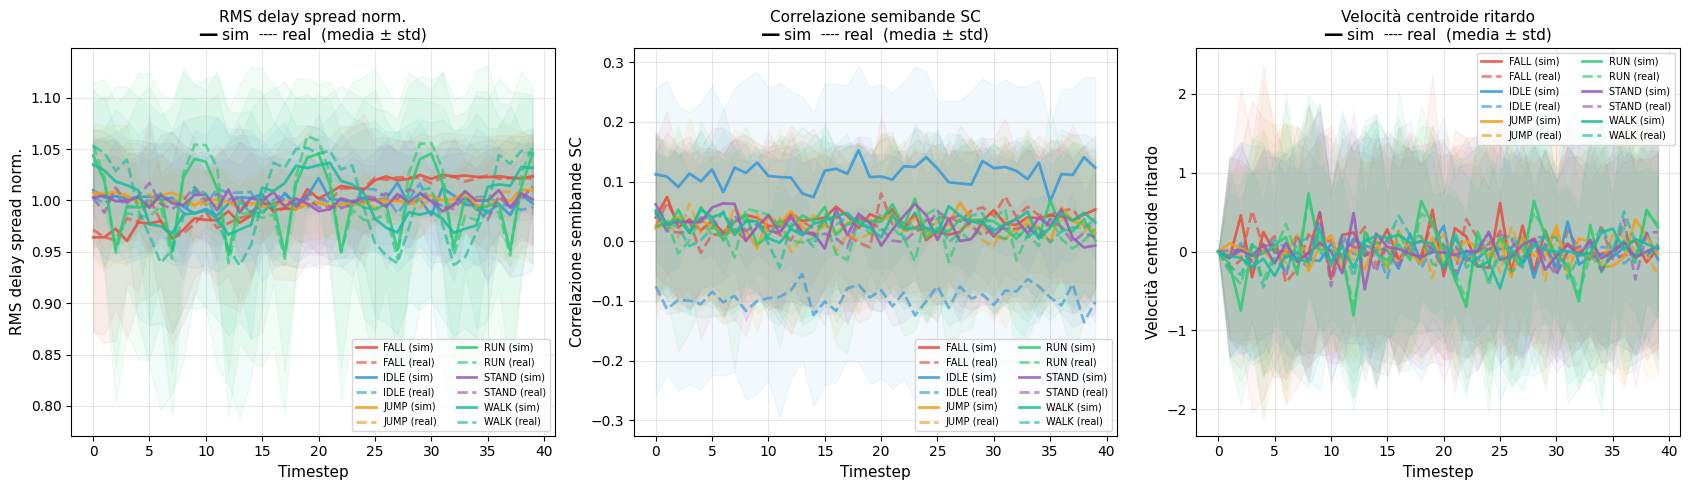

In [57]:
delay_feats = [
    ('spread_rel', 'RMS delay spread norm.'),
    ('sc_corr',    'Correlazione semibande SC'),
    ('vel_rel',    'Velocità centroide ritardo'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
t = np.arange(N_STEPS)

for ax, (feat_key, feat_label) in zip(axes, delay_feats):
    for label in CLASSES:
        col = CLASS_COLORS[label]
        for dset_name in ('sim', 'real'):
            arr = feats[dset_name][label][feat_key]
            mu, sd = arr.mean(axis=0), arr.std(axis=0)
            ls    = DSET_STYLE[dset_name]
            alpha = DSET_ALPHA[dset_name]
            ax.plot(t, mu, label=f'{label} ({dset_name})', color=col,
                    linewidth=2, linestyle=ls, alpha=alpha)
            ax.fill_between(t, mu - sd, mu + sd, color=col, alpha=0.06)
    ax.set_xlabel('Timestep', fontsize=11)
    ax.set_ylabel(feat_label, fontsize=11)
    ax.set_title(f'{feat_label}\n━━ sim  ╌╌ real  (media ± std)', fontsize=11)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/doppler/delay_features_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

## 14 · Fisher Discriminant Ratio  |  SIM vs REAL

$$\text{FDR}(i,j) = \frac{(\mu_i - \mu_j)^2}{\sigma_i^2 + \sigma_j^2}$$

Pannello sinistro = SIM, pannello destro = REAL — stessa scala colore per ogni pannello.
La riga rossa ★ indica la coppia **STAND vs JUMP** (più difficile nello zero-shot).

Se una feature ha FDR alto in SIM ma basso in REAL → **non è trasferibile** (fonte del domain gap).

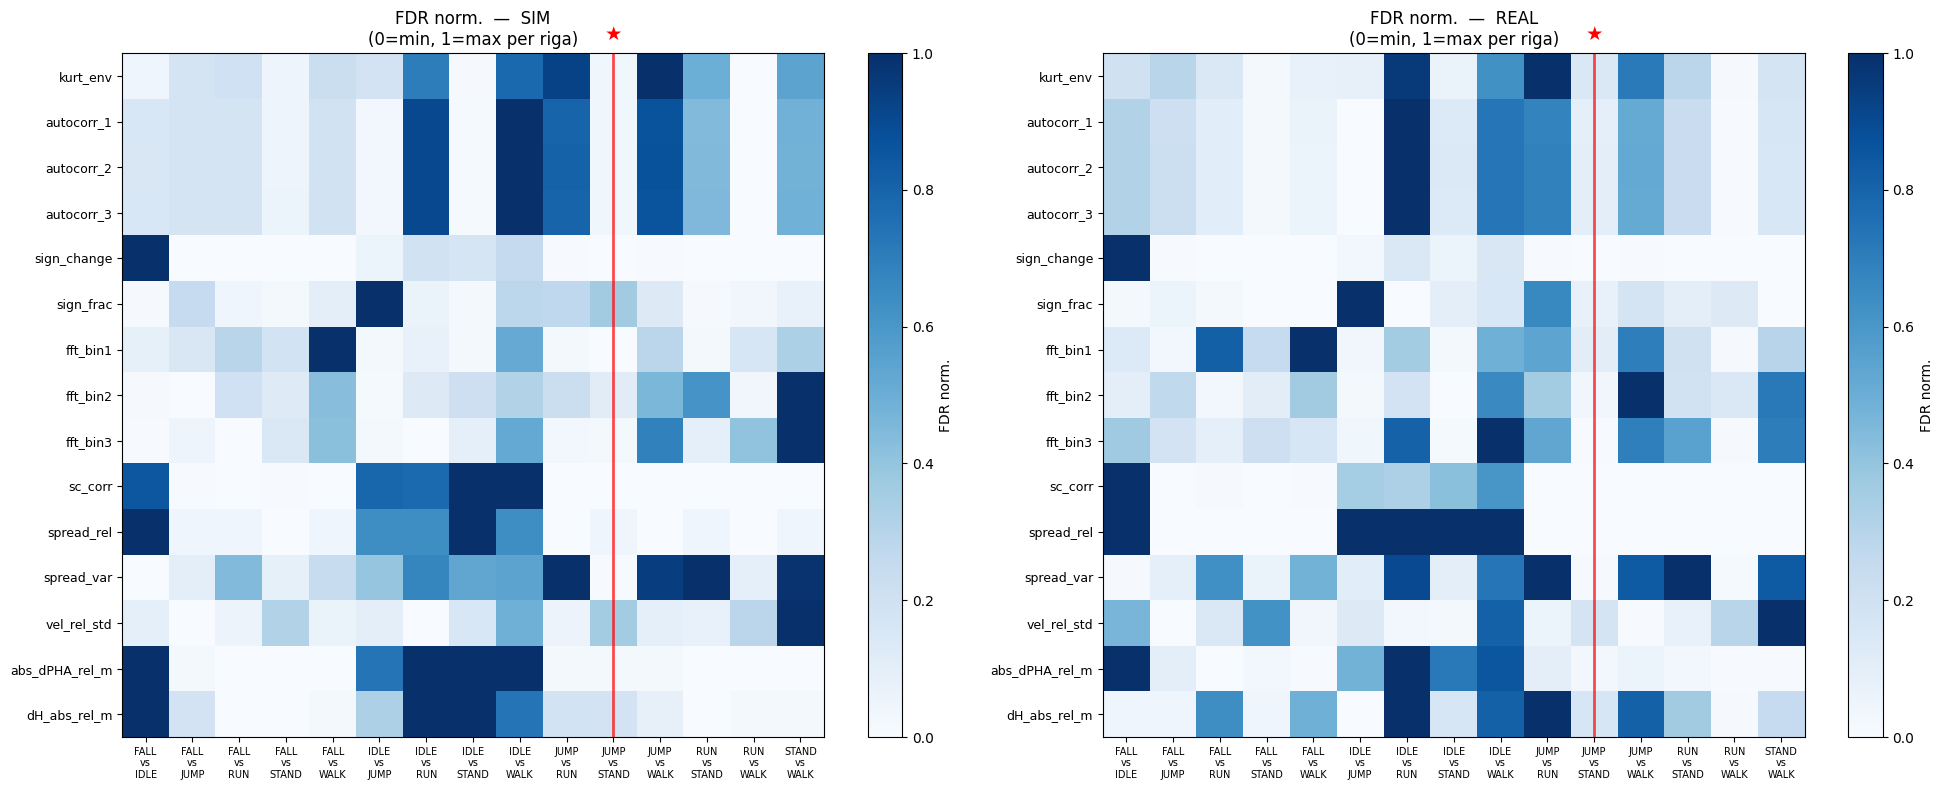


Top features STAND vs JUMP:
  Feature                 FDR SIM   FDR REAL        Δ%
  ------------------------------------------------------
  vel_rel_std              0.1272     0.0249     -80.4% ←!
  sign_change              0.1158     0.0890     -23.1%
  autocorr_2               0.0268     0.0842    +214.0%
  autocorr_1               0.0263     0.0830    +216.2%
  autocorr_3               0.0256     0.0851    +232.5%
  kurt_env                 0.0248     0.1179    +375.3%
  sign_frac                0.0221     0.0024     -89.3% ←!
  fft_bin2                 0.0090     0.0088      -2.5%
  fft_bin3                 0.0038     0.0003     -92.9% ←!
  spread_var               0.0022     0.0059    +171.8%


In [ ]:
all_scalar_def = [
    ('kurt_env',       lambda d, c: feats[d][c]['kurt_env']),
    ('autocorr_1',     lambda d, c: feats[d][c]['autocorr'][1]),
    ('autocorr_2',     lambda d, c: feats[d][c]['autocorr'][2]),
    ('autocorr_3',     lambda d, c: feats[d][c]['autocorr'][3]),
    ('sign_change',    lambda d, c: feats[d][c]['sign_change_t'].mean(axis=1)),
    ('sign_frac',      lambda d, c: feats[d][c]['sign_frac_t'].mean(axis=1)),
    ('fft_bin1',       lambda d, c: feats[d][c]['fft_norm'][:, 0]),
    ('fft_bin2',       lambda d, c: feats[d][c]['fft_norm'][:, 1]),
    ('fft_bin3',       lambda d, c: feats[d][c]['fft_norm'][:, 2]),
    ('sc_corr',        lambda d, c: feats[d][c]['sc_corr'].mean(axis=1)),
    ('spread_rel',     lambda d, c: feats[d][c]['spread_rel'].mean(axis=1)),
    ('spread_var',     lambda d, c: feats[d][c]['spread_rel'].var(axis=1)),
    ('vel_rel_std',    lambda d, c: feats[d][c]['vel_rel'].std(axis=1)),
    ('abs_dPHA_rel_m', lambda d, c: feats[d][c]['abs_dPHA_rel'].mean(axis=(1, 2))),
    ('dH_abs_rel_m',   lambda d, c: feats[d][c]['dH_abs_rel'].mean(axis=(1, 2))),
]
feat_names = [fn for fn, _ in all_scalar_def]
pairs      = [(c1, c2) for i, c1 in enumerate(CLASSES) for c2 in CLASSES[i+1:]]
pair_labels = [f'{a}\nvs\n{b}' for a, b in pairs]
sj_idx     = next(i for i, (a, b) in enumerate(pairs) if {a, b} == {'STAND', 'JUMP'})

fdr_matrices = {}
for dset_name in ('sim', 'real'):
    mat = np.zeros((len(feat_names), len(pairs)))
    for fi, (fn, getter) in enumerate(all_scalar_def):
        for pi, (c1, c2) in enumerate(pairs):
            v1, v2 = getter(dset_name, c1), getter(dset_name, c2)
            mat[fi, pi] = (v1.mean() - v2.mean()) ** 2 / (v1.var() + v2.var() + 1e-9)
    fdr_matrices[dset_name] = mat

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, dset_name in zip(axes, ('sim', 'real')):
    fdr_norm = fdr_matrices[dset_name] / (fdr_matrices[dset_name].max(axis=1, keepdims=True) + 1e-9)
    im = ax.imshow(fdr_norm, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(pairs)));     ax.set_xticklabels(pair_labels, fontsize=7)
    ax.set_yticks(range(len(feat_names))); ax.set_yticklabels(feat_names, fontsize=9)
    ax.set_title(f'FDR norm.  —  {dset_name.upper()}\n(0=min, 1=max per riga)', fontsize=12)
    plt.colorbar(im, ax=ax, label='FDR norm.')
    ax.axvline(sj_idx, color='red', linewidth=2, alpha=0.7)
    ax.text(sj_idx, -0.8, '★', color='red', fontsize=14, ha='center')

plt.tight_layout()
plt.savefig('figs/doppler/fdr_separability_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()

# Confronto top features STAND vs JUMP tra sim e real
print('\nTop features STAND vs JUMP:')
print(f"  {'Feature':20s}  {'FDR SIM':>9s}  {'FDR REAL':>9s}  {'Δ%':>8s}")
print('  ' + '-' * 54)
sj_sim  = fdr_matrices['sim'][:, sj_idx]
sj_real = fdr_matrices['real'][:, sj_idx]
for i in np.argsort(sj_sim)[::-1][:10]:
    delta = (sj_real[i] - sj_sim[i]) / (sj_sim[i] + 1e-9) * 100
    marker = ' ←!' if delta < -50 else ''   # feature non trasferibile
    print(f'  {feat_names[i]:20s}  {sj_sim[i]:9.4f}  {sj_real[i]:9.4f}  {delta:+8.1f}%{marker}')

## 15 · Focus: STAND vs JUMP  |  SIM vs REAL

Le due classi più confuse nel zero-shot (CNN: ~38% STAND → JUMP).

Profili temporali di tutte le features per STAND e JUMP, con **━━ sim** e **╌╌ real** sovrapposti, per capire quale feature mantiene il suo potere discriminante nel dominio reale e quale collassa.

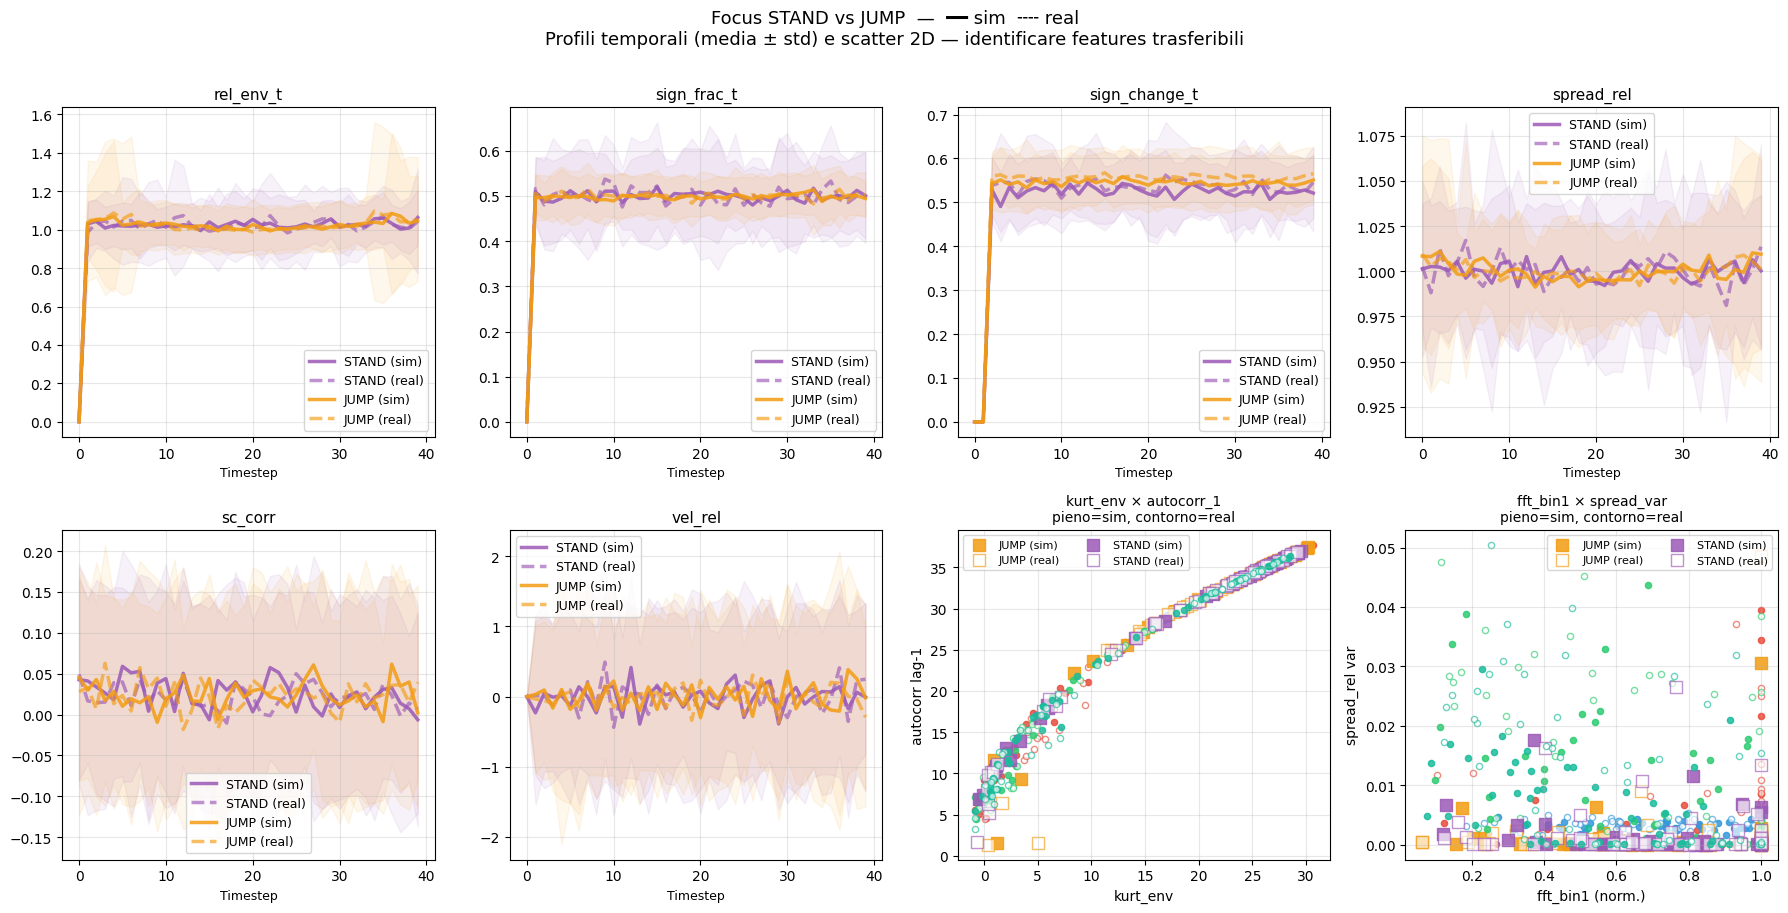

In [ ]:
t = np.arange(N_STEPS)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

temporal_feats_sj = [
    ('rel_env_t',    'rel_env_t'),
    ('sign_frac_t',  'sign_frac_t'),
    ('sign_change_t','sign_change_t'),
    ('spread_rel',   'spread_rel'),
    ('sc_corr',      'sc_corr'),
    ('vel_rel',      'vel_rel'),
]

for ax_idx, (feat_key, feat_label) in enumerate(temporal_feats_sj):
    ax = axes.ravel()[ax_idx]
    for label in ['STAND', 'JUMP']:
        col = CLASS_COLORS[label]
        for dset_name in ('sim', 'real'):
            arr   = feats[dset_name][label][feat_key]
            mu, sd = arr.mean(axis=0), arr.std(axis=0)
            ls    = DSET_STYLE[dset_name]
            alpha = DSET_ALPHA[dset_name]
            ax.plot(t, mu, label=f'{label} ({dset_name})', color=col,
                    linewidth=2.5, linestyle=ls, alpha=alpha)
            ax.fill_between(t, mu - sd, mu + sd, color=col, alpha=0.08)
    ax.set_title(feat_label, fontsize=11)
    ax.set_xlabel('Timestep', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Scatter: kurt_env × autocorr_1 (tutti le classi, STAND/JUMP evidenziati)
ax = axes.ravel()[6]
for label in CLASSES:
    col = CLASS_COLORS[label]
    marker = 's' if label in ('STAND', 'JUMP') else 'o'
    sz     = 70  if label in ('STAND', 'JUMP') else 20
    for dset_name in ('sim', 'real'):
        x = feats[dset_name][label]['kurt_env']
        y = feats[dset_name][label]['autocorr'][1]
        fc = col if dset_name == 'sim' else 'white'
        ec = col
        lbl = f'{label} ({dset_name})' if label in ('STAND', 'JUMP') else '_'
        ax.scatter(x, y, facecolors=fc, edgecolors=ec, linewidths=1.0,
                   s=sz, marker=marker, alpha=DSET_ALPHA[dset_name], label=lbl)
ax.set_xlabel('kurt_env', fontsize=10)
ax.set_ylabel('autocorr lag-1', fontsize=10)
ax.set_title('kurt_env × autocorr_1\npieno=sim, contorno=real', fontsize=10)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Scatter: fft_bin1 × spread_var
ax = axes.ravel()[7]
for label in CLASSES:
    col = CLASS_COLORS[label]
    marker = 's' if label in ('STAND', 'JUMP') else 'o'
    sz     = 70  if label in ('STAND', 'JUMP') else 20
    for dset_name in ('sim', 'real'):
        x = feats[dset_name][label]['fft_norm'][:, 0]
        y = feats[dset_name][label]['spread_rel'].var(axis=1)
        fc = col if dset_name == 'sim' else 'white'
        lbl = f'{label} ({dset_name})' if label in ('STAND', 'JUMP') else '_'
        ax.scatter(x, y, facecolors=fc, edgecolors=col, linewidths=1.0,
                   s=sz, marker=marker, alpha=DSET_ALPHA[dset_name], label=lbl)
ax.set_xlabel('fft_bin1 (norm.)', fontsize=10)
ax.set_ylabel('spread_rel var', fontsize=10)
ax.set_title('fft_bin1 × spread_var\npieno=sim, contorno=real', fontsize=10)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

fig.suptitle('Focus STAND vs JUMP  —  ━━ sim  ╌╌ real\n'
             'Profili temporali (media ± std) e scatter 2D — identificare features trasferibili', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figs/doppler/stand_vs_jump_sim_vs_real.png', bbox_inches='tight', dpi=100)
plt.show()